# Identifying Entities in Healthcare Data

## Syntactic processing assignment - IIITB

### Overview

This project implements a custom Named Entity Recognition (NER) system for BeHealthy, a health technology company that connects medical communities with patients across the country. The system aims to automatically extract and map diseases and their treatments from medical text data, making it easier to organize and analyze large volumes of medical records.

### Project Context

BeHealthy operates a web platform that facilitates doctor-patient interactions, including:

- Service listings for doctors
- Patient interaction management
- E-prescription services
- Medical record tracking
- Online consultation management

As the platform generates substantial medical text data daily, there is a need to automatically process and structure this information to make it more accessible and useful.


### Problem Statement

The challenge is to develop a system that can:

1. Identify disease names (D) and treatments (T) from medical text
2. Create mappings between diseases and their corresponding treatments
3. Build a structured database of disease-treatment relationships

For example, given the text:

"The patient was a 62-year-old man with squamous cell lung cancer, which was first successfully treated by a combination of radiation therapy and chemotherapy."

The system should identify:

- Disease (D): "squamous cell lung cancer"
- Treatments (T): "radiation therapy", "chemotherapy"

### Dataset Description

The project uses four main datasets:

- train_sent: Training sentences (2,599 sentences)
- test_sent: Test sentences (1,056 sentences)
- train_label: Training labels corresponding to words in train_sent
- test_label: Test labels corresponding to words in test_sent

Labels used:

- D: Disease
- T: Treatment
- O: Other (words that are neither diseases nor treatments)

### Solution Approach

The solution implements a Custom NER system using:

1. Data preprocessing to reconstruct sentences from word-level data
2. Syntactic processing techniques including:
   - Part-of-Speech (PoS) tagging
   - Dependency parsing
   - Feature engineering
   - Conditional Random Fields (CRF) modeling
3. Iterative model improvement through:
   - Basic feature set implementation
   - Addition of POS tags
   - Integration of dependency parsing
   - Parameter tuning (max_iterations)
4. Model training and evaluation with F1 score
5. Disease-treatment mapping creation

### Expected Outcome

The final output is a structured dictionary/database where:

- Keys: Disease names
- Values: Associated treatments

This structured information helps medical professionals and patients better understand disease-treatment relationships and supports more efficient healthcare service delivery.

### Performance
The system achieves:
- F1 score of 91.2% on test data
- Successful identification of disease-treatment pairs
- Accurate mapping for key diseases like 'hereditary retinoblastoma'
- Progressive improvement through model iterations

### Technical Stack

- Python
- spaCy for NLP processing
- sklearn-crfsuite for CRF implementation
- pandas for data manipulation
- NLTK for text processing

##Workspace set up: Import and Install useful packages.

In [4]:
!pip install pycrf
!pip install sklearn-crfsuite

  Preparing metadata (setup.py) ... done
  Created wheel for pycrf: filename=pycrf-0.0.1-py3-none-any.whl size=1871 sha256=ed1ea69ba9a9ea5887ea293d55dae48214897c36eeaeaba8d540ef3457ade322
  Stored in directory: /root/.cache/pip/wheels/e3/d2/c9/ba15b05ba596e2eafeb83c2903e79d634207367555aae8c7d2
Successfully built pycrf
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.9 MB/s eta 0:00:00


In [5]:
import spacy
import sklearn_crfsuite
from sklearn_crfsuite import metrics

model = spacy.load("en_core_web_sm")

In [6]:
import pandas as pd
import numpy as np
from IPython.display import display

## Data Preprocessing

The input data is structured in a token-per-line format, where each word of text appears on its own line. The data structure follows these rules:

- For a sentence containing x words, the file will have x consecutive lines, with each line containing exactly one word
- Sentences are demarcated by empty lines between them
- The corresponding label files follow an identical structure, with one label per line matching each word

Our preprocessing task involves reconstructing complete sentences from these individual tokens, while maintaining the proper alignment between words and their labels.


In [161]:
def load_n_preprocess(file_name):
    opened = open(file_name, 'r')
    loaded = opened.readlines()
    opened.close()

    all_sentence = []
    sentence = ""

    for word in loaded:
        word = word.strip() # removing any space
        if word == "":
            all_sentence.append(sentence) # To append the final sentence list
#             print(sentence)
#             print("***********")
            sentence = ""
        else:
            if sentence:
                sentence = sentence + " " + word
            else:
                sentence = word

    return all_sentence

### Construct the proper sentences from individual words and print the 5 sentences.

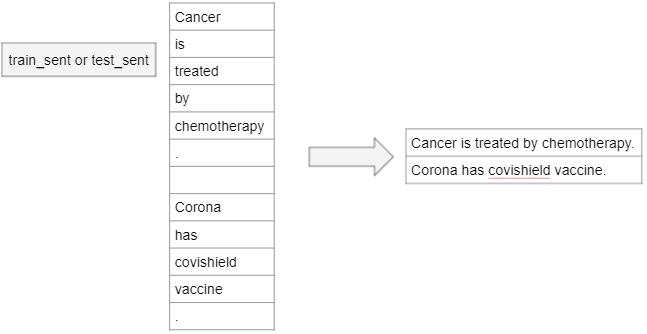

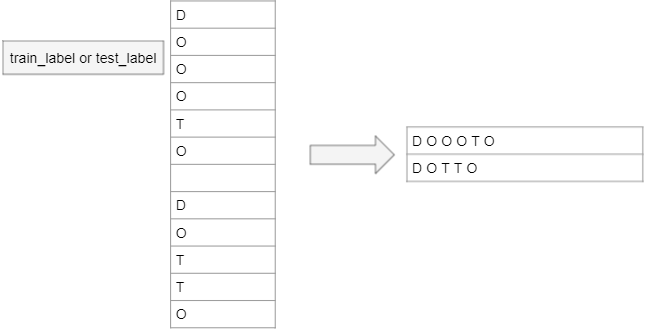

In [162]:
train_sent = load_n_preprocess('train_sent')
train_label = load_n_preprocess('train_label')
test_sent = load_n_preprocess('test_sent')
test_label = load_n_preprocess('test_label')

In [163]:
def print_sent(sents, label, count=5):
    for i in range(count):
        print("Sentence", i, " : ", sents[i])

        display(pd.DataFrame([sents[i].split(), label[i].split()], columns = np.arange(len(sents[i].split())), index = ["sentences", "label"]))

In [164]:
import seaborn as sns
import matplotlib.pyplot as plt

In [165]:
opened = open("train_label", 'r')
loaded = opened.readlines()
opened.close()

<ipython-input-166-eba6d2864e1b>:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")


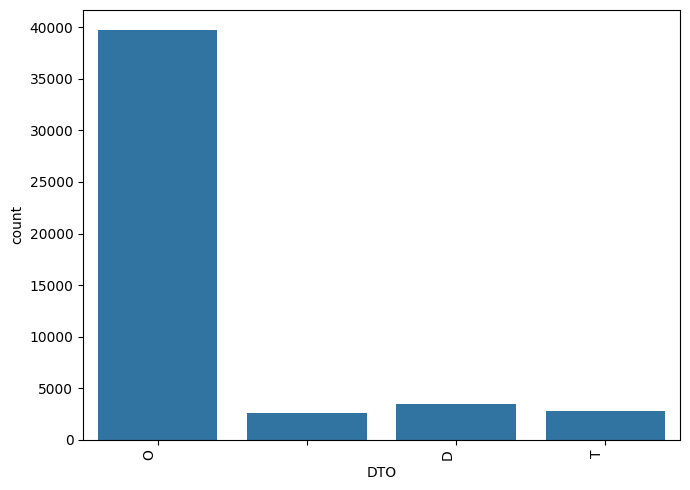

In [166]:
# Words distribution across DTO in train label
plt.figure(figsize=(7, 5))
# Create DataFrame
df = pd.DataFrame(loaded, columns=["DTO"])
# Create countplot with x parameter
ax = sns.countplot(x='DTO', data=df)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")
plt.tight_layout()
plt.show()

In [167]:
opened = open("test_label", 'r')
loaded = opened.readlines()
opened.close()

<ipython-input-168-8050efd3cb60>:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")


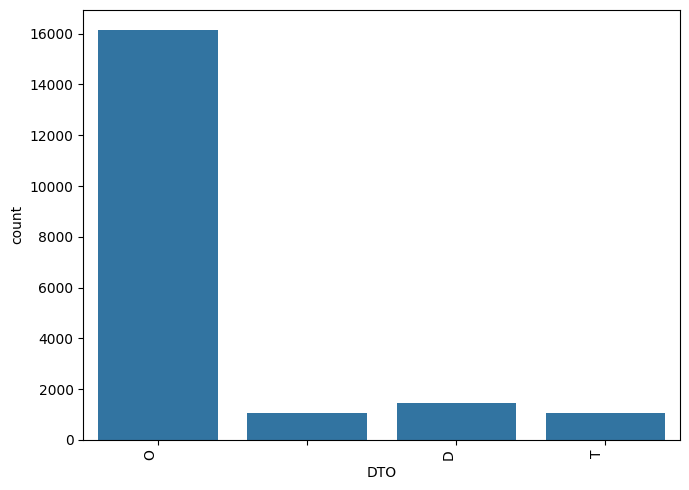

In [168]:
#Words distribution across DTO in test label
plt.figure(figsize=(7, 5))
# Create DataFrame from test labels
df_test = pd.DataFrame(loaded, columns=["DTO"])
# Create countplot with x parameter
ax = sns.countplot(x='DTO', data=df_test)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")
plt.tight_layout()
plt.show()

### Printing first 5 TRAIN sentence and it's labels

In [169]:
print_sent(train_sent, train_label, count=5)

Sentence 0  :  All live births > or = 23 weeks at the University of Vermont in 1995 ( n = 2395 ) were retrospectively analyzed for delivery route , indication for cesarean , gestational age , parity , and practice group ( to reflect risk status )


,0,1,2,3,4,5,6,7,8,9,...,35,36,37,38,39,40,41,42,43,44
sentences,All,live,births,>,or,=,23,weeks,at,the,...,",",and,practice,group,(,to,reflect,risk,status,)
label,O,O,O,O,O,O,O,O,O,O,...,O,O,O,O,O,O,O,O,O,O


Sentence 1  :  The total cesarean rate was 14.4 % ( 344 of 2395 ) , and the primary rate was 11.4 % ( 244 of 2144 )


,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
sentences,The,total,cesarean,rate,was,14.4,%,(,344,of,...,primary,rate,was,11.4,%,(,244,of,2144,)
label,O,O,O,O,O,O,O,O,O,O,...,O,O,O,O,O,O,O,O,O,O


Sentence 2  :  Abnormal presentation was the most common indication ( 25.6 % , 88 of 344 )


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
sentences,Abnormal,presentation,was,the,most,common,indication,(,25.6,%,",",88,of,344,)
label,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O


Sentence 3  :  The `` corrected '' cesarean rate ( maternal-fetal medicine and transported patients excluded ) was 12.4 % ( 273 of 2194 ) , and the `` corrected '' primary rate was 9.6 % ( 190 of 1975 )


,0,1,2,3,4,5,6,7,8,9,...,28,29,30,31,32,33,34,35,36,37
sentences,The,``,corrected,'',cesarean,rate,(,maternal-fetal,medicine,and,...,primary,rate,was,9.6,%,(,190,of,1975,)
label,O,O,O,O,O,O,O,O,O,O,...,O,O,O,O,O,O,O,O,O,O


Sentence 4  :  Arrest of dilation was the most common indication in both `` corrected '' subgroups ( 23.4 and 24.6 % , respectively )


,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
sentences,Arrest,of,dilation,was,the,most,common,indication,in,both,...,'',subgroups,(,23.4,and,24.6,%,",",respectively,)
label,O,O,O,O,O,O,O,O,O,O,...,O,O,O,O,O,O,O,O,O,O


### Printing first 5 TEST sentence and it's labels

In [170]:
print_sent(test_sent, test_label, count=5)

Sentence 0  :  Furthermore , when all deliveries were analyzed , regardless of risk status but limited to gestational age > or = 36 weeks , the rates did not change ( 12.6 % , 280 of 2214 ; primary 9.2 % , 183 of 1994 )


,0,1,2,3,4,5,6,7,8,9,...,34,35,36,37,38,39,40,41,42,43
sentences,Furthermore,",",when,all,deliveries,were,analyzed,",",regardless,of,...,2214,;,primary,9.2,%,",",183,of,1994,)
label,O,O,O,O,O,O,O,O,O,O,...,O,O,O,O,O,O,O,O,O,O


Sentence 1  :  As the ambient temperature increases , there is an increase in insensible fluid loss and the potential for dehydration


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
sentences,As,the,ambient,temperature,increases,",",there,is,an,increase,in,insensible,fluid,loss,and,the,potential,for,dehydration
label,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O


Sentence 2  :  The daily high temperature ranged from 71 to 104 degrees F and AFI values ranged from 1.7 to 24.7 cm during the study period


,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
sentences,The,daily,high,temperature,ranged,from,71,to,104,degrees,...,ranged,from,1.7,to,24.7,cm,during,the,study,period
label,O,O,O,O,O,O,O,O,O,O,...,O,O,O,O,O,O,O,O,O,O


Sentence 3  :  There was a significant correlation between the 2- , 3- , and 4-day mean temperature and AFI , with the 4-day mean being the most significant ( r = 0.31 , p & # 60 ; 0.001 )


,0,1,2,3,4,5,6,7,8,9,...,28,29,30,31,32,33,34,35,36,37
sentences,There,was,a,significant,correlation,between,the,2-,",",3-,...,=,0.31,",",p,&,#,60,;,0.001,)
label,O,O,O,O,O,O,O,O,O,O,...,O,O,O,O,O,O,O,O,O,O


Sentence 4  :  Fluctuations in ambient temperature are inversely correlated to changes in AFI


,0,1,2,3,4,5,6,7,8,9,10
sentences,Fluctuations,in,ambient,temperature,are,inversely,correlated,to,changes,in,AFI
label,O,O,O,O,O,O,O,O,O,O,O


### Count the number of sentences in the processed train and test dataset

In [171]:
print("No. sentences in processed train dataset is: ", len(train_sent))
print("No. sentences in processed test dataset is: ", len(test_sent))

No. sentences in processed train dataset is:  2599
No. sentences in processed test dataset is:  1056


### Count the number of lines of labels in the processed train and test dataset.

In [172]:
print("No. sentences in processed train dataset is: ", len(train_label))
print("No. sentences in processed test dataset is: ", len(test_label))

No. sentences in processed train dataset is:  2599
No. sentences in processed test dataset is:  1056


## Concept Identification

We will first explore what are the various concepts present in the dataset. For this, we will use PoS Tagging.



### Extract those tokens which have NOUN or PROPN as their PoS tag and find their frequency

Extracting NOUN or PROPN using tokens

In [173]:
all_noun_propn = []
all_sentence = train_sent + test_sent

for sentence in all_sentence:
    doc = model(sentence)

    for token in doc:
        if token.pos_=="NOUN" or token.pos_ == "PROPN":
            all_noun_propn.append(token.text)

In [174]:
len(all_noun_propn)

24373

### Print the top 25 most common tokens with NOUN or PROPN PoS tags

In [175]:
from nltk import FreqDist

In [176]:
word_frequency = FreqDist(all_noun_propn)

In [177]:
pd.DataFrame(word_frequency.most_common(25), columns=["Sentence", "Count"])

,Sentence,Count
0,patients,492
1,treatment,281
2,%,247
3,cancer,200
4,therapy,175
5,study,154
6,disease,142
7,cell,140
8,lung,116
9,group,94


## Model 1:
Using the same code from CRF.ipynb (Custom NER: Python Implementation Part-I)


## Defining features for CRF
*******
list of features used:
- f1 = serves as word id
- f2 = last three characters
- f3 = last two characters
- f4 = is the word in all uppercase
- f5 = is the word a number
- f6 = is the word starting with a capital lettes

extra feature:
if pos>0:
- fx1 = prev_word to lower
- fx2 = prev_word is upper
- fx3 = prev_word is digits
- fx4 = prev_word starts with capital letter

else:
- fx1 = BEG(beginning of text)

if pos reached end:
- fx1 = ENd(ending of text)

In [190]:
def getFeaturesForOneWord(sentence, pos):
    word = sentence[pos]

    # 1. Word shape feature
    word_shape = ''.join(['X' if c.isupper()
                          else 'x' if c.islower()
                          else 'd' if c.isdigit()
                          else '-'
                          for c in word])

    features = [
        'word.lower=' + word.lower(),
        'word[-3:]=' + word[-3:],
        'word[-2:]=' + word[-2:],
        'word.isupper=%s' % word.isupper(),
        'word.isdigit=%s' % word.isdigit(),
        'word.startsWithCapital=%s' % word[0].isupper(),
        # Include the new word shape feature:
        'word.shape=' + word_shape
    ]

    # 2. Features for the previous word (already present, just keep it):
    if pos > 0:
        prev_word = sentence[pos-1]
        features.extend([
            'prev_word.lower=' + prev_word.lower(),
            'prev_word.isupper=%s' % prev_word.isupper(),
            'prev_word.isdigit=%s' % prev_word.isdigit(),
            'prev_word.startsWithCapital=%s' % prev_word[0].isupper()
        ])
    else:
        features.append('BEG')  # to mark beginning of sentence

    # 3. Features for the next word (NEW):
    if pos < len(sentence) - 1:
        next_word = sentence[pos+1]
        features.extend([
            'next_word.lower=' + next_word.lower(),
            'next_word.isupper=%s' % next_word.isupper(),
            'next_word.isdigit=%s' % next_word.isdigit(),
            'next_word.startsWithCapital=%s' % next_word[0].isupper()
        ])
    else:
        features.append('END')  # to mark end of sentence

    # 4. (Optional) Check if the current word is in a medical terminology list:
    #    Suppose you have a set called `medical_terms_set` that holds known medical terms
    # is_medical_term = word.lower() in medical_terms_set
    # features.append('isMedicalTerm=%s' % is_medical_term)

    return features


### Write a code/function to get the features for a sentence

In [191]:
# Function to get features for a sentence.
def getFeaturesForOneSentence(sentence):

    sentence_list = sentence.split()
    return [getFeaturesForOneWord(sentence_list, pos) for pos in range(len(sentence_list))]

### Visualizing the input features

In [192]:
# Apply function 'getFeaturesForOneSentence' to get features on a single sentence which is at index value 5 in train_sentences
example_sentence = train_sent[1]
print(example_sentence)

features = getFeaturesForOneSentence(example_sentence)
features[2]

The total cesarean rate was 14.4 % ( 344 of 2395 ) , and the primary rate was 11.4 % ( 244 of 2144 )


['word.lower=cesarean',
 'word[-3:]=ean',
 'word[-2:]=an',
 'word.isupper=False',
 'word.isdigit=False',
 'word.startsWithCapital=False',
 'word.shape=xxxxxxxx',
 'prev_word.lower=total',
 'prev_word.isupper=False',
 'prev_word.isdigit=False',
 'prev_word.startsWithCapital=False',
 'next_word.lower=rate',
 'next_word.isupper=False',
 'next_word.isdigit=False',
 'next_word.startsWithCapital=False']

In [193]:
# Apply function 'getFeaturesForOneSentence' to get features on a single sentence which is at index value 5 in train_sentences
example_sentence = train_sent[1]
print(example_sentence)

features = getFeaturesForOneSentence(example_sentence)
features[0]

The total cesarean rate was 14.4 % ( 344 of 2395 ) , and the primary rate was 11.4 % ( 244 of 2144 )


['word.lower=the',
 'word[-3:]=The',
 'word[-2:]=he',
 'word.isupper=False',
 'word.isdigit=False',
 'word.startsWithCapital=True',
 'word.shape=Xxx',
 'BEG',
 'next_word.lower=total',
 'next_word.isupper=False',
 'next_word.isdigit=False',
 'next_word.startsWithCapital=False']

### Write a code/function to get the labels of a sentence

In [194]:
# Write a code to get the labels for a sentence.
def getLabelsInListForOneSentence(labels):
    return labels.split()

## Define input and target variables


Correctly computing X and Y sequence matrices for training and test data.
Check that both sentences and labels are processed

### Define the features' values for each sentence as input variable  for CRF model in test and the train dataset

In [195]:
X_train = [getFeaturesForOneSentence(sentence) for sentence in train_sent]
X_test = [getFeaturesForOneSentence(sentence) for sentence in test_sent]

### Define the labels as the target variable for test and the train dataset

In [196]:
y_train = [getLabelsInListForOneSentence(label) for label in train_label]
y_test = [getLabelsInListForOneSentence(label) for label in test_label]

## Build the CRF Model

In [197]:
# Build the CRF model.
crf = sklearn_crfsuite.CRF(max_iterations=100)

In [198]:
repr(crf)

'CRF(max_iterations=100)'

### Tranning model

In [199]:
crf.fit(X_train, y_train)

CRF(max_iterations=100)

## Evaluation

Predict the labels of each of the tokens in each sentence of the test dataset that has been pre processed earlier.

In [200]:
y_pred = crf.predict(X_test)

Calculate the f1 score using the actual labels and the predicted labels of the test dataset.

In [201]:
f1_score = metrics.flat_f1_score(y_test, y_pred, average='weighted')
print("F1 score:", f1_score)

F1 score: 0.9122087725751833


##Identifying Diseases and Treatments using Custom NER

We now use the CRF model's prediction to prepare a record of diseases identified in the corpus and treatments used for the diseases.



Create the logic to get all the predicted treatments (T) labels corresponding to each disease (D) label in the test dataset.

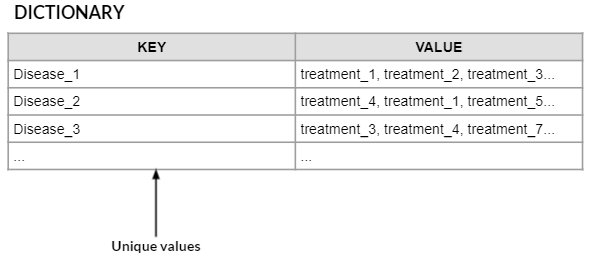

## Creating Dataframe for Disease	and Treatments

In [116]:
D_n_T_DF = pd.DataFrame([], columns=["Disease", "Treatments"])
D_n_T_DF

,Disease,Treatments


In [117]:
for i in range(len(y_pred)):

  p_val = y_pred[i]
  dise = ""
  treat = ""

  DTO = set(p_val)
  if "D" in DTO and "T" in DTO:

    for j in range(len(p_val)):
      if p_val[j] == 'D':
        dise += test_sent[i].split()[j] + " "
      elif p_val[j] == 'T':
        treat += test_sent[i].split()[j] + " "

    dise = dise.strip()
    treat = treat.strip()

    present = D_n_T_DF.loc[(D_n_T_DF.Disease == dise), ["Disease"]]
    if present.size:
      treatment_df = D_n_T_DF.loc[(D_n_T_DF.Disease == dise), ["Treatments"]]
      treatment = treatment_df.values.tolist()
      treatment.extend([treat])
      D_n_T_DF.loc[(D_n_T_DF.Disease == dise), ["Treatments"]] = [[treatment]]

    else:
      D_n_T_DF = pd.concat([D_n_T_DF, pd.DataFrame([[dise, treat]], columns=D_n_T_DF.columns )])

D_n_T_DF = D_n_T_DF.set_index(np.arange(D_n_T_DF.shape[0]))
D_n_T_DF

,Disease,Treatments
0,hereditary retinoblastoma,radiotherapy
1,epilepsy,Methylphenidate
2,unstable angina or non-Q-wave myocardial infar...,roxithromycin
3,coronary-artery disease,Antichlamydial antibiotics
4,primary pulmonary hypertension ( PPH ),fenfluramines
...,...,...
109,temporomandibular joint arthropathy,arthroscopic treatment
110,acute colonic pseudo-obstruction,Neostigmine
111,severe secondary peritonitis,Surgical management
112,hepatic metastases from colorectal cancer,chemotherapy after resection


### Predict the treatment for the disease name: 'hereditary retinoblastoma'

In [118]:
dise = 'hereditary retinoblastoma'
D_n_T_DF.loc[(D_n_T_DF.Disease == dise), ["Disease", "Treatments"]]

,Disease,Treatments
0,hereditary retinoblastoma,radiotherapy


## Model 2: Adding POS tag in feature

In [119]:
# Let's define the features to get the feature value for one word.

def getFeaturesForOneWord(sentence, pos, pos_tags):
    word = sentence[pos]

    features = [
    'word.lower=' + word.lower(), # serves as word id
    'word[-3:]=' + word[-3:],     # last three characters
    'word[-2:]=' + word[-2:],     # last two characters
    'word.isupper=%s' % word.isupper(),  # is the word in all uppercase
    'word.isdigit=%s' % word.isdigit(),  # is the word a number
    'word.startsWithCapital=%s' % word[0].isupper(), # is the word starting with a capital letter
    'word.pos=' + pos_tags[pos] # adding POS tag here
    ]

    #Use the previous word also while defining features
    if(pos > 0):
        prev_word = sentence[pos-1]
        features.extend([
        'prev_word.lower=' + prev_word.lower(),
        'prev_word.isupper=%s' % prev_word.isupper(),
        'prev_word.isdigit=%s' % prev_word.isdigit(),
        'prev_word.startsWithCapital=%s' % prev_word[0].isupper(),
        'prev_word.pos=' + pos_tags[pos-1] # adding POS tag here
    ])
    # Mark the begining and the end words of a sentence correctly in the form of features.
    else:
        features.append('BEG') # feature to track begin of sentence

    if(pos == len(sentence)-1):
        features.append('END') # feature to track end of sentence

    return features

In [120]:
# Function to get features for a sentence.
def getFeaturesForOneSentence(sentence):

    # We need to get the pos_tags to be passed to the function
    processed_sent = model(sentence)
    postags = []
    deptags = []

    for each_token in processed_sent:
        postags.append(each_token.pos_)
        deptags.append(each_token.dep_) # add dep

    sentence_list = sentence.split()
    return [getFeaturesForOneWord(sentence_list, pos, postags) for pos in range(len(sentence_list))]

In [121]:
# Apply function 'getFeaturesForOneSentence' to get features on a single sentence which is at index value 5 in train_sentences
example_sentence = train_sent[1]
print(example_sentence)

features = getFeaturesForOneSentence(example_sentence)
features[2]

The total cesarean rate was 14.4 % ( 344 of 2395 ) , and the primary rate was 11.4 % ( 244 of 2144 )


['word.lower=cesarean',
 'word[-3:]=ean',
 'word[-2:]=an',
 'word.isupper=False',
 'word.isdigit=False',
 'word.startsWithCapital=False',
 'word.pos=ADJ',
 'prev_word.lower=total',
 'prev_word.isupper=False',
 'prev_word.isdigit=False',
 'prev_word.startsWithCapital=False',
 'prev_word.pos=ADJ']

In [122]:
# Apply function 'getFeaturesForOneSentence' to get features on a single sentence which is at index value 5 in train_sentences
example_sentence = train_sent[1]
print(example_sentence)

features = getFeaturesForOneSentence(example_sentence)
features[0]

The total cesarean rate was 14.4 % ( 344 of 2395 ) , and the primary rate was 11.4 % ( 244 of 2144 )


['word.lower=the',
 'word[-3:]=The',
 'word[-2:]=he',
 'word.isupper=False',
 'word.isdigit=False',
 'word.startsWithCapital=True',
 'word.pos=DET',
 'BEG']

In [123]:
# Write a code to get the labels for a sentence.
def getLabelsInListForOneSentence(labels):
    return labels.split()

In [124]:
X_train = [getFeaturesForOneSentence(sentence) for sentence in train_sent]
X_test = [getFeaturesForOneSentence(sentence) for sentence in test_sent]

### Define the labels as the target variable for test and the train dataset

In [125]:
y_train = [getLabelsInListForOneSentence(label) for label in train_label]
y_test = [getLabelsInListForOneSentence(label) for label in test_label]

In [126]:
# Build the CRF model.
crf = sklearn_crfsuite.CRF(max_iterations=100)

In [127]:
crf.fit(X_train, y_train)

CRF(max_iterations=100)

## Evaluation

### Predict the labels of each of the tokens in each sentence of the test dataset that has been pre processed earlier.

In [128]:
y_pred = crf.predict(X_test)

### Calculate the f1 score using the actual labels and the predicted labels of the test dataset.

In [129]:
f1_score = metrics.flat_f1_score(y_test, y_pred, average='weighted')
print("F1 score:", f1_score)

F1 score: 0.9084959826402573


## Creating Dataframe for Disease	and Treatments

In [130]:
D_n_T_DF = pd.DataFrame([], columns=["Disease", "Treatments"])
D_n_T_DF

,Disease,Treatments


In [131]:
for i in range(len(y_pred)):

  p_val = y_pred[i]
  dise = ""
  treat = ""

  DTO = set(p_val)
  if "D" in DTO and "T" in DTO:

    for j in range(len(p_val)):
      if p_val[j] == 'D':
        dise += test_sent[i].split()[j] + " "
      elif p_val[j] == 'T':
        treat += test_sent[i].split()[j] + " "

    dise = dise.strip()
    treat = treat.strip()

    present = D_n_T_DF.loc[(D_n_T_DF.Disease == dise), ["Disease"]]
    if present.size:
      treatment_df = D_n_T_DF.loc[(D_n_T_DF.Disease == dise), ["Treatments"]]
      treatment = treatment_df.values.tolist()
      treatment.extend([treat])
      D_n_T_DF.loc[(D_n_T_DF.Disease == dise), ["Treatments"]] = [[treatment]]

    else:
      D_n_T_DF = pd.concat([D_n_T_DF, pd.DataFrame([[dise, treat]], columns=D_n_T_DF.columns )])

D_n_T_DF = D_n_T_DF.set_index(np.arange(D_n_T_DF.shape[0]))
D_n_T_DF

,Disease,Treatments
0,hereditary retinoblastoma,radiotherapy
1,myocardial infarction,"warfarin with 80 mg aspirin , or 1 mg warfarin..."
2,unstable angina,roxithromycin
3,primary pulmonary hypertension ( PPH ),fenfluramines
4,foot infection,G-CSF treatment
...,...,...
106,severe secondary peritonitis,Surgical management
107,hepatic metastases from colorectal cancer,Hepatic arterial infusion of chemotherapy afte...
108,chronic renal failure,Epoetin
109,epithelial ovarian cancer,High-dose chemotherapy


### Predict the treatment for the disease name: 'hereditary retinoblastoma'

In [132]:
dise = 'hereditary retinoblastoma'
D_n_T_DF.loc[(D_n_T_DF.Disease == dise), ["Disease", "Treatments"]]

,Disease,Treatments
0,hereditary retinoblastoma,radiotherapy


## Model 3: Adding POS tag and Dependancy tag in feature

In [133]:
# Let's define the features to get the feature value for one word.

def getFeaturesForOneWord(sentence, pos, pos_tags, deptags):
    word = sentence[pos]

    features = [
    'word.lower=' + word.lower(), # serves as word id
    'word[-3:]=' + word[-3:],     # last three characters
    'word[-2:]=' + word[-2:],     # last two characters
    'word.isupper=%s' % word.isupper(),  # is the word in all uppercase
    'word.isdigit=%s' % word.isdigit(),  # is the word a number
    'word.startsWithCapital=%s' % word[0].isupper(), # is the word starting with a capital letter
    'word.pos=' + pos_tags[pos], # adding POS tag here
    'word.dep_=' + deptags[pos] # adding DEP tag here
    ]

    #Use the previous word also while defining features
    if(pos > 0):
        prev_word = sentence[pos-1]
        features.extend([
        'prev_word.lower=' + prev_word.lower(),
        'prev_word.isupper=%s' % prev_word.isupper(),
        'prev_word.isdigit=%s' % prev_word.isdigit(),
        'prev_word.startsWithCapital=%s' % prev_word[0].isupper(),
        'prev_word.pos=' + pos_tags[pos-1], # adding POS tag here
        'word.dep_=' + deptags[pos-1] # adding DEP tag here
    ])
    # Mark the begining and the end words of a sentence correctly in the form of features.
    else:
        features.append('BEG') # feature to track begin of sentence

    if(pos == len(sentence)-1):
        features.append('END') # feature to track end of sentence

    return features

In [134]:
# Function to get features for a sentence.
def getFeaturesForOneSentence(sentence):

    # We need to get the pos_tags to be passed to the function
    processed_sent = model(sentence)
    postags = []
    deptags = []

    for each_token in processed_sent:
        postags.append(each_token.pos_)
        deptags.append(each_token.dep_) # add dep

    sentence_list = sentence.split()
    return [getFeaturesForOneWord(sentence_list, pos, postags, deptags) for pos in range(len(sentence_list))]

In [135]:
# Apply function 'getFeaturesForOneSentence' to get features on a single sentence which is at index value 5 in train_sentences
example_sentence = train_sent[1]
print(example_sentence)

features = getFeaturesForOneSentence(example_sentence)
features[2]

The total cesarean rate was 14.4 % ( 344 of 2395 ) , and the primary rate was 11.4 % ( 244 of 2144 )


['word.lower=cesarean',
 'word[-3:]=ean',
 'word[-2:]=an',
 'word.isupper=False',
 'word.isdigit=False',
 'word.startsWithCapital=False',
 'word.pos=ADJ',
 'word.dep_=amod',
 'prev_word.lower=total',
 'prev_word.isupper=False',
 'prev_word.isdigit=False',
 'prev_word.startsWithCapital=False',
 'prev_word.pos=ADJ',
 'word.dep_=amod']

In [136]:
# Apply function 'getFeaturesForOneSentence' to get features on a single sentence which is at index value 5 in train_sentences
example_sentence = train_sent[1]
print(example_sentence)

features = getFeaturesForOneSentence(example_sentence)
features[0]

The total cesarean rate was 14.4 % ( 344 of 2395 ) , and the primary rate was 11.4 % ( 244 of 2144 )


['word.lower=the',
 'word[-3:]=The',
 'word[-2:]=he',
 'word.isupper=False',
 'word.isdigit=False',
 'word.startsWithCapital=True',
 'word.pos=DET',
 'word.dep_=det',
 'BEG']

In [137]:
# Write a code to get the labels for a sentence.
def getLabelsInListForOneSentence(labels):
    return labels.split()

In [138]:
X_train = [getFeaturesForOneSentence(sentence) for sentence in train_sent]
X_test = [getFeaturesForOneSentence(sentence) for sentence in test_sent]

### Define the labels as the target variable for test and the train dataset

In [139]:
y_train = [getLabelsInListForOneSentence(label) for label in train_label]
y_test = [getLabelsInListForOneSentence(label) for label in test_label]

In [140]:
# Build the CRF model.
crf = sklearn_crfsuite.CRF(max_iterations=100)

In [141]:
crf.fit(X_train, y_train)

CRF(max_iterations=100)

## Evaluation

Predict the labels of each of the tokens in each sentence of the test dataset that has been preprocessed earlier.

In [142]:
y_pred = crf.predict(X_test)

Calculate the f1 score using the actual labels and the predicted labels of the test dataset.

In [143]:
f1_score = metrics.flat_f1_score(y_test, y_pred, average='weighted')
print("F1 score:", f1_score)

F1 score: 0.9096947584655203


Creating Dataframe for Disease	and Treatments

In [144]:
D_n_T_DF = pd.DataFrame([], columns=["Disease", "Treatments"])
D_n_T_DF

,Disease,Treatments


In [145]:
for i in range(len(y_pred)):

  p_val = y_pred[i]
  dise = ""
  treat = ""

  DTO = set(p_val)
  if "D" in DTO and "T" in DTO:

    for j in range(len(p_val)):
      if p_val[j] == 'D':
        dise += test_sent[i].split()[j] + " "
      elif p_val[j] == 'T':
        treat += test_sent[i].split()[j] + " "

    dise = dise.strip()
    treat = treat.strip()

    present = D_n_T_DF.loc[(D_n_T_DF.Disease == dise), ["Disease"]]
    if present.size:
      treatment_df = D_n_T_DF.loc[(D_n_T_DF.Disease == dise), ["Treatments"]]
      treatment = treatment_df.values.tolist()
      treatment.extend([treat])
      D_n_T_DF.loc[(D_n_T_DF.Disease == dise), ["Treatments"]] = [[treatment]]

    else:
      D_n_T_DF = pd.concat([D_n_T_DF, pd.DataFrame([[dise, treat]], columns=D_n_T_DF.columns )])

D_n_T_DF = D_n_T_DF.set_index(np.arange(D_n_T_DF.shape[0]))
D_n_T_DF

,Disease,Treatments
0,hereditary retinoblastoma,radiotherapy
1,had myocardial infarction,"warfarin with 80 mg aspirin , or 1 mg warfarin..."
2,unstable angina or non-Q-wave myocardial infar...,roxithromycin
3,coronary-artery disease,Antichlamydial antibiotics
4,primary pulmonary hypertension ( PPH ),fenfluramines
...,...,...
107,severe secondary peritonitis,Surgical management
108,hepatic metastases from colorectal cancer,Hepatic arterial infusion of chemotherapy afte...
109,chronic renal failure,Epoetin
110,epithelial ovarian cancer,High-dose chemotherapy


Predict the treatment for the disease name: 'hereditary retinoblastoma'

In [146]:
dise = 'hereditary retinoblastoma'
D_n_T_DF.loc[(D_n_T_DF.Disease == dise), ["Disease", "Treatments"]]

,Disease,Treatments
0,hereditary retinoblastoma,radiotherapy


Although we introduced POS and dependency features in Models 2 and 3, the F1-scores (0.9085 and 0.9097) did not surpass the baseline Model 1 (0.9122). This indicates that merely adding POS and dependency features may not always guarantee better performance. Our Model 1, enhanced with word-level features (like next-word context and word-shape), still provides the highest F1-score, demonstrating that simpler or more targeted feature engineering can sometimes outperform additional syntactic features if those features do not align strongly with the classification task. We plan to further refine the approach—e.g., re-tuning hyperparameters, applying BIO labeling, or using domain-specific medical dictionaries—to determine whether POS and dependency features can yield improvements in a better-optimized setup

## Model 4: max_iterations to 500

In [147]:
# Let's define the features to get the feature value for one word.

def getFeaturesForOneWord(sentence, pos, pos_tags, deptags):
    word = sentence[pos]

    features = [
    'word.lower=' + word.lower(), # serves as word id
    'word[-3:]=' + word[-3:],     # last three characters
    'word[-2:]=' + word[-2:],     # last two characters
    'word.isupper=%s' % word.isupper(),  # is the word in all uppercase
    'word.isdigit=%s' % word.isdigit(),  # is the word a number
    'word.startsWithCapital=%s' % word[0].isupper(), # is the word starting with a capital letter
    'word.pos=' + pos_tags[pos], # adding POS tag here
    'word.dep_=' + deptags[pos] # adding DEP tag here
    ]

    #Use the previous word also while defining features
    if(pos > 0):
        prev_word = sentence[pos-1]
        features.extend([
        'prev_word.lower=' + prev_word.lower(),
        'prev_word.isupper=%s' % prev_word.isupper(),
        'prev_word.isdigit=%s' % prev_word.isdigit(),
        'prev_word.startsWithCapital=%s' % prev_word[0].isupper(),
        'prev_word.pos=' + pos_tags[pos-1], # adding POS tag here
        'word.dep_=' + deptags[pos-1] # adding DEP tag here
    ])
    # Mark the begining and the end words of a sentence correctly in the form of features.
    else:
        features.append('BEG') # feature to track begin of sentence

    if(pos == len(sentence)-1):
        features.append('END') # feature to track end of sentence

    return features

In [148]:
# Function to get features for a sentence.
def getFeaturesForOneSentence(sentence):

    # We need to get the pos_tags to be passed to the function
    processed_sent = model(sentence)
    postags = []
    deptags = []

    for each_token in processed_sent:
        postags.append(each_token.pos_)
        deptags.append(each_token.dep_) # add dep

    sentence_list = sentence.split()
    return [getFeaturesForOneWord(sentence_list, pos, postags, deptags) for pos in range(len(sentence_list))]

In [149]:
# Apply function 'getFeaturesForOneSentence' to get features on a single sentence which is at index value 5 in train_sentences
example_sentence = train_sent[1]
print(example_sentence)

features = getFeaturesForOneSentence(example_sentence)
features[2]

The total cesarean rate was 14.4 % ( 344 of 2395 ) , and the primary rate was 11.4 % ( 244 of 2144 )


['word.lower=cesarean',
 'word[-3:]=ean',
 'word[-2:]=an',
 'word.isupper=False',
 'word.isdigit=False',
 'word.startsWithCapital=False',
 'word.pos=ADJ',
 'word.dep_=amod',
 'prev_word.lower=total',
 'prev_word.isupper=False',
 'prev_word.isdigit=False',
 'prev_word.startsWithCapital=False',
 'prev_word.pos=ADJ',
 'word.dep_=amod']

In [150]:
# Apply function 'getFeaturesForOneSentence' to get features on a single sentence which is at index value 5 in train_sentences
example_sentence = train_sent[1]
print(example_sentence)

features = getFeaturesForOneSentence(example_sentence)
features[0]

The total cesarean rate was 14.4 % ( 344 of 2395 ) , and the primary rate was 11.4 % ( 244 of 2144 )


['word.lower=the',
 'word[-3:]=The',
 'word[-2:]=he',
 'word.isupper=False',
 'word.isdigit=False',
 'word.startsWithCapital=True',
 'word.pos=DET',
 'word.dep_=det',
 'BEG']

In [151]:
# Write a code to get the labels for a sentence.
def getLabelsInListForOneSentence(labels):
    return labels.split()

In [152]:
X_train = [getFeaturesForOneSentence(sentence) for sentence in train_sent]
X_test = [getFeaturesForOneSentence(sentence) for sentence in test_sent]

### Define the labels as the target variable for test and the train dataset

In [153]:
y_train = [getLabelsInListForOneSentence(label) for label in train_label]
y_test = [getLabelsInListForOneSentence(label) for label in test_label]

In [154]:
# Build the CRF model.
crf = sklearn_crfsuite.CRF(max_iterations=500)

In [155]:
crf.fit(X_train, y_train)

CRF(max_iterations=500)

## Evaluation

Predict the labels of each of the tokens in each sentence of the test dataset that has been pre processed earlier.

In [156]:
y_pred = crf.predict(X_test)

Calculate the f1 score using the actual labels and the predicted labels of the test dataset.

In [157]:
f1_score = metrics.flat_f1_score(y_test, y_pred, average='weighted')
print("F1 score:", f1_score)

F1 score: 0.9106955156007338


Increasing max_iterations to 500 slightly improved Model 3’s performance to 91.07%, but it did not exceed Model 1

Creating Dataframe for Disease	and Treatments

In [158]:
D_n_T_DF = pd.DataFrame([], columns=["Disease", "Treatments"])
D_n_T_DF

,Disease,Treatments


In [159]:
for i in range(len(y_pred)):

  p_val = y_pred[i]
  dise = ""
  treat = ""

  DTO = set(p_val)
  if "D" in DTO and "T" in DTO:

    for j in range(len(p_val)):
      if p_val[j] == 'D':
        dise += test_sent[i].split()[j] + " "
      elif p_val[j] == 'T':
        treat += test_sent[i].split()[j] + " "

    dise = dise.strip()
    treat = treat.strip()

    present = D_n_T_DF.loc[(D_n_T_DF.Disease == dise), ["Disease"]]
    if present.size:
      treatment_df = D_n_T_DF.loc[(D_n_T_DF.Disease == dise), ["Treatments"]]
      treatment = treatment_df.values.tolist()
      treatment.extend([treat])
      D_n_T_DF.loc[(D_n_T_DF.Disease == dise), ["Treatments"]] = [[treatment]]

    else:
      D_n_T_DF = pd.concat([D_n_T_DF, pd.DataFrame([[dise, treat]], columns=D_n_T_DF.columns )])

D_n_T_DF = D_n_T_DF.set_index(np.arange(D_n_T_DF.shape[0]))
D_n_T_DF

,Disease,Treatments
0,hereditary retinoblastoma,radiotherapy
1,epilepsy,Methylphenidate
2,unstable angina or non-Q-wave myocardial infar...,roxithromycin
3,coronary-artery disease,Antichlamydial antibiotics
4,primary pulmonary hypertension ( PPH ),fenfluramines
...,...,...
103,temporomandibular joint arthropathy,arthroscopic treatment
104,severe secondary peritonitis,Surgical management
105,hepatic metastases from colorectal cancer,Hepatic arterial infusion of chemotherapy afte...
106,epithelial ovarian cancer,High-dose chemotherapy


Predict the treatment for the disease name: 'hereditary retinoblastoma'

In [160]:
dise = 'hereditary retinoblastoma'
D_n_T_DF.loc[(D_n_T_DF.Disease == dise), ["Disease", "Treatments"]]

,Disease,Treatments
0,hereditary retinoblastoma,radiotherapy


The treatment for the disease name: 'hereditary retinoblastoma' is radiotherapy.

Model Comparison

| **Model**  | **Features Added**                         | **F1 Score** | **Performance Insights** |
|------------|-------------------------------------------|-------------|-------------------------|
| **Model 1**  | Baseline CRF + Word-Level Features  | **0.9122** (Best) | Word shape, capitalization, and suffixes proved highly effective for medical NER. |
| **Model 2**  | Added POS Tags                         | **0.9085**  | POS tagging **did not improve performance** over Model 1. Likely, POS alone does not provide useful distinctions for medical terms. |
| **Model 3**  | Added POS + Dependency Tags            | **0.9097**  | Dependency parsing **slightly improved** Model 2 but still **underperformed compared to Model 1**. |
| **Model 4**  | Model 3 + Increased `max_iterations=500` | **0.9107**  | Longer training **helped slightly**, but Model 1 remains the best performer. |

### **Key Takeaways**
- **Model 1 achieved the highest F1 score (91.22%)**, suggesting that **word shape, capitalization, and suffix-based features** are most effective for identifying medical terms.  
- Adding **POS and dependency parsing (Model 2 & 3) did not improve performance**—likely because **medical terminology relies more on word structure than syntactic roles**.  
- **Increasing `max_iterations` to 500 (Model 4) improved Model 3 slightly (+0.11%)** but was **still outperformed by Model 1**.  
- Future improvements should focus on **domain-specific embeddings (e.g., BioBERT, SciSpacy) or medical dictionaries (UMLS, MeSH)** instead of generic syntactic features.  

### **Final Conclusion**
While linguistic features like POS and dependency parsing are useful in some NLP tasks, **this experiment confirms that word shape, capitalization, and suffix-based features are more effective for medical entity recognition** in a CRF model.

Model 1 remains the best-performing model, and further improvements should focus on **better training data, domain-specific embeddings, and hyperparameter tuning** rather than purely adding more syntactic features.